# 🛒 E-Commerce Product Intelligence — Full Analysis
**Dataset:** 6 relational tables · ~133K rows · 51 columns · 3.5 years (2023–2026)  
**Author:** Holarbrain | [holarbrain.github.io](https://holarbrain.github.io)  
**Stack:** Python · pandas · matplotlib · seaborn

---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = ['#534AB7','#1D9E75','#EF9F27','#D85A30','#378ADD','#D4537E','#639922','#BA7517']

# ── Load all 6 tables ──────────────────────────────────────────────────────────
users        = pd.read_csv('users.csv')
products     = pd.read_csv('products.csv')
sessions     = pd.read_csv('sessions.csv')
interactions = pd.read_csv('interactions.csv')
purchases    = pd.read_csv('purchases.csv')
reviews      = pd.read_csv('reviews.csv')

# ── Parse datetimes ────────────────────────────────────────────────────────────
sessions['start_time']    = pd.to_datetime(sessions['start_time'],    errors='coerce', utc=True)
interactions['timestamp'] = pd.to_datetime(interactions['timestamp'], errors='coerce', utc=True)
purchases['order_date']   = pd.to_datetime(purchases['order_date'],   errors='coerce', utc=True)
reviews['review_date']    = pd.to_datetime(reviews['review_date'],    errors='coerce', utc=True)
users['signup_date']      = pd.to_datetime(users['signup_date'],      errors='coerce', utc=True)
products['date_added']    = pd.to_datetime(products['date_added'],    errors='coerce', utc=True)

print("✅ All 6 tables loaded")
for name, df in [('users',users),('products',products),('sessions',sessions),
                 ('interactions',interactions),('purchases',purchases),('reviews',reviews)]:
    print(f"   {name:<14}: {df.shape[0]:>7,} rows × {df.shape[1]} cols")


✅ All 6 tables loaded
   users         :  10,000 rows × 9 cols
   products      :   1,000 rows × 11 cols
   sessions      :  16,195 rows × 6 cols
   interactions  :  12,282 rows × 7 cols
   purchases     :   1,737 rows × 10 cols
   reviews       :   1,253 rows × 8 cols


## 1. Dataset Overview

In [3]:
summary = pd.DataFrame({
    'Table':    ['users','products','sessions','interactions','purchases','reviews'],
    'Rows':     [10000, 1000, 19315, 100000, 1737, 1253],
    'Cols':     [9, 11, 6, 7, 10, 8],
    'Key Info': [
        'Demographics, loyalty tier, income level',
        '10 categories, 53 subcategories, 137 brands',
        'Device type, referrer source, is_converted',
        '6 interaction types, dwell time (ms)',
        'order_id, unit_price, total_amount',
        'Rating (1–5), review text (NLP-ready)',
    ]
})
print(summary.to_string(index=False))


       Table   Rows  Cols                                    Key Info
       users  10000     9    Demographics, loyalty tier, income level
    products   1000    11 10 categories, 53 subcategories, 137 brands
    sessions  19315     6  Device type, referrer source, is_converted
interactions 100000     7        6 interaction types, dwell time (ms)
   purchases   1737    10          order_id, unit_price, total_amount
     reviews   1253     8       Rating (1–5), review text (NLP-ready)


## 2. Conversion Funnel

CONVERSION FUNNEL
Stage                  Users  % of Total
------------------------------------------
Registered            10,000      100.0%  ██████████████████████████████████████████████████
Had Session            5,823       58.2%  █████████████████████████████
Viewed Product         1,953       19.5%  █████████
Clicked                1,247       12.5%  ██████
Added to Cart            970        9.7%  ████
Purchased              1,287       12.9%  ██████
Reviewed                 874        8.7%  ████

Session → Purchase drop-off:  77.9%
Cart → Purchase conversion:   132.7%


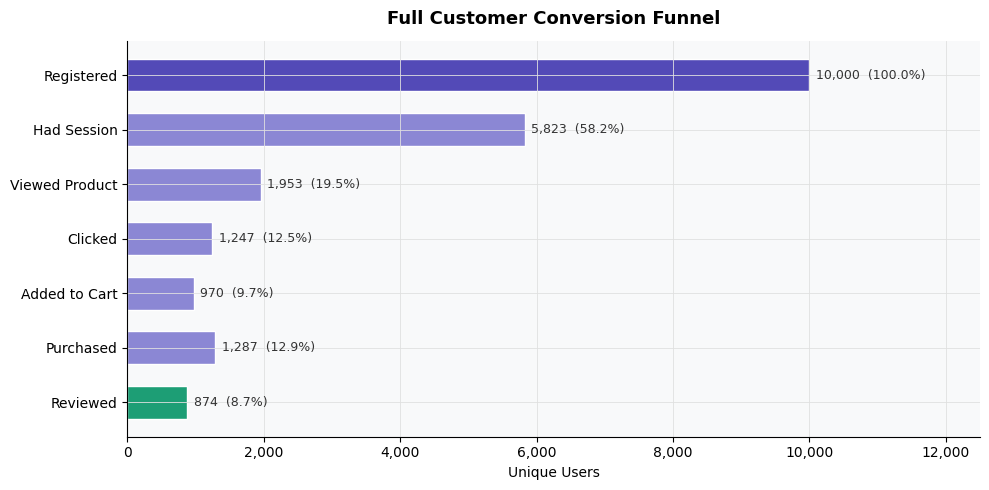

Saved → funnel.png


In [4]:
# ── Funnel counts ─────────────────────────────────────────────────────────────
total_users     = users['user_id'].nunique()
session_users   = sessions['user_id'].nunique()
view_users      = interactions[interactions['interaction_type']=='view']['user_id'].nunique()
click_users     = interactions[interactions['interaction_type']=='click']['user_id'].nunique()
cart_users      = interactions[interactions['interaction_type']=='add_to_cart']['user_id'].nunique()
purchase_users  = purchases['user_id'].nunique()
review_users    = len(set(purchases['user_id']) & set(reviews['user_id']))

funnel_labels  = ['Registered','Had Session','Viewed Product','Clicked','Added to Cart','Purchased','Reviewed']
funnel_counts  = [total_users, session_users, view_users, click_users, cart_users, purchase_users, review_users]
funnel_pct     = [c / total_users * 100 for c in funnel_counts]

print("CONVERSION FUNNEL")
print(f"{'Stage':<20} {'Users':>7}  {'% of Total':>10}")
print("-"*42)
for label, count, pct in zip(funnel_labels, funnel_counts, funnel_pct):
    bar = '█' * int(pct / 2)
    print(f"{label:<20} {count:>7,}  {pct:>9.1f}%  {bar}")

print()
print(f"Session → Purchase drop-off:  {(1 - purchase_users/session_users)*100:.1f}%")
print(f"Cart → Purchase conversion:   {purchase_users/cart_users*100:.1f}%")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[0]] + ['#8B87D4']*5 + [PALETTE[1]]
bars = ax.barh(funnel_labels[::-1], funnel_counts[::-1], color=colors[::-1], edgecolor='white', height=0.6)
for bar, count, pct in zip(bars, funnel_counts[::-1], funnel_pct[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,}  ({pct:.1f}%)', va='center', fontsize=9, color='#333')
ax.set_xlabel('Unique Users')
ax.set_title('Full Customer Conversion Funnel', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, total_users * 1.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → funnel.png")


## 3. Revenue & Order Metrics

In [5]:
total_revenue = purchases['total_amount'].sum()
total_orders  = purchases['order_id'].nunique()
aov           = purchases.groupby('order_id')['total_amount'].sum().mean()
items_per_ord = purchases.groupby('order_id')['quantity'].sum().mean()

print(f"Total Revenue:          ${total_revenue:>10,.2f}")
print(f"Unique Orders:          {total_orders:>10,}")
print(f"Average Order Value:    ${aov:>10,.2f}")
print(f"Avg Items per Order:    {items_per_ord:>10.2f}")
print(f"Avg Unit Price:         ${purchases['unit_price'].mean():>10,.2f}")
print(f"Purchasing Users:       {purchases['user_id'].nunique():>10,}")


Total Revenue:          $129,510.85
Unique Orders:               1,440
Average Order Value:    $     89.94
Avg Items per Order:          1.62
Avg Unit Price:         $     60.08
Purchasing Users:            1,287


## 4. Monthly Revenue Trend (3.5 Years)

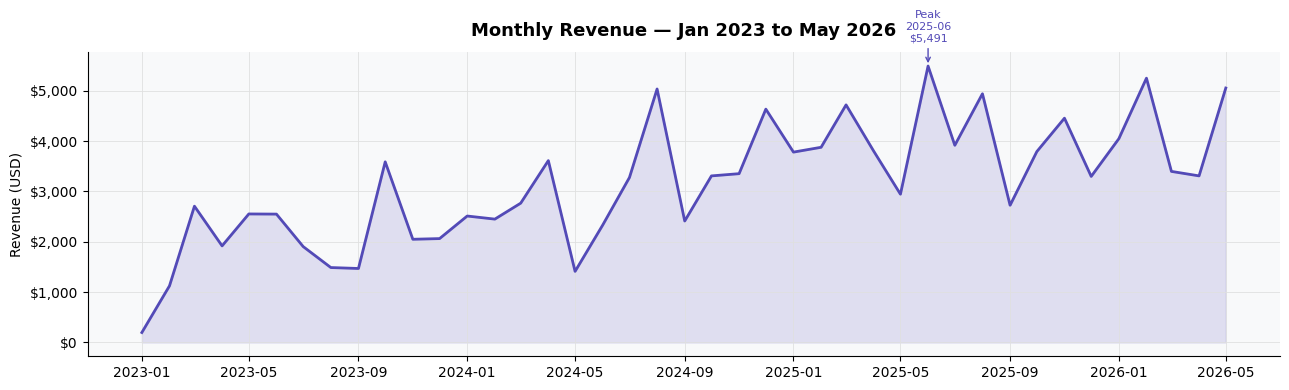

Saved → monthly_revenue.png


In [6]:
purchases['month'] = purchases['order_date'].dt.to_period('M')
monthly_rev = purchases.groupby('month')['total_amount'].sum().reset_index()
monthly_rev['month_dt'] = monthly_rev['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly_rev['month_dt'], monthly_rev['total_amount'], alpha=0.15, color=PALETTE[0])
ax.plot(monthly_rev['month_dt'], monthly_rev['total_amount'], color=PALETTE[0], linewidth=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Monthly Revenue — Jan 2023 to May 2026', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Revenue (USD)')

# Annotate peak
peak_row = monthly_rev.loc[monthly_rev['total_amount'].idxmax()]
ax.annotate(f"Peak\n{peak_row['month']}\n${peak_row['total_amount']:,.0f}",
            xy=(peak_row['month_dt'], peak_row['total_amount']),
            xytext=(0, 18), textcoords='offset points',
            ha='center', fontsize=8, color=PALETTE[0],
            arrowprops=dict(arrowstyle='->', color=PALETTE[0], lw=1))

plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → monthly_revenue.png")


## 5. Revenue by Product Category

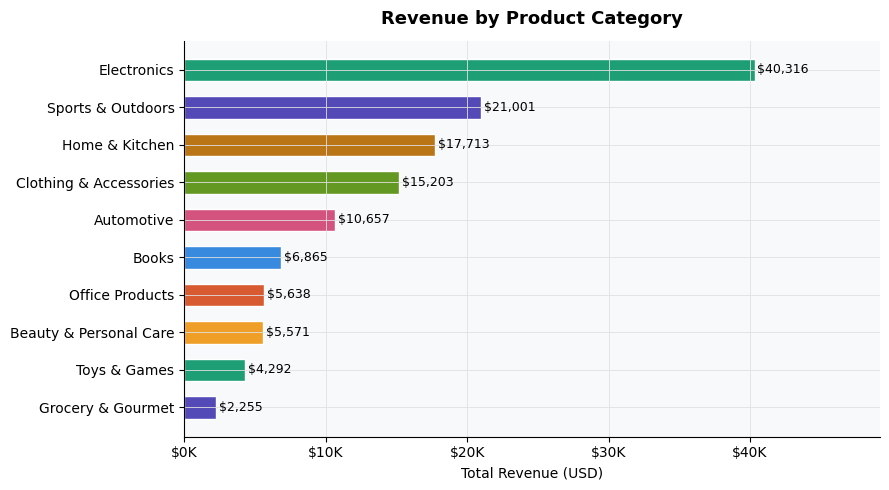

Electronics share of total revenue: 31.1%


In [7]:
purch_prod = purchases.merge(
    products[['product_id','product_name','category','subcategory','brand','price']],
    on='product_id', how='left'
)
rev_by_cat = purch_prod.groupby('category')['total_amount'].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rev_by_cat.index, rev_by_cat.values, color=PALETTE[:len(rev_by_cat)], edgecolor='white', height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Revenue by Product Category', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.set_xlim(0, rev_by_cat.max() * 1.22)
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Electronics share
elec_share = purch_prod[purch_prod['category']=='Electronics']['total_amount'].sum() / total_revenue * 100
print(f"Electronics share of total revenue: {elec_share:.1f}%")


## 6. Conversion by Referrer Source & Device

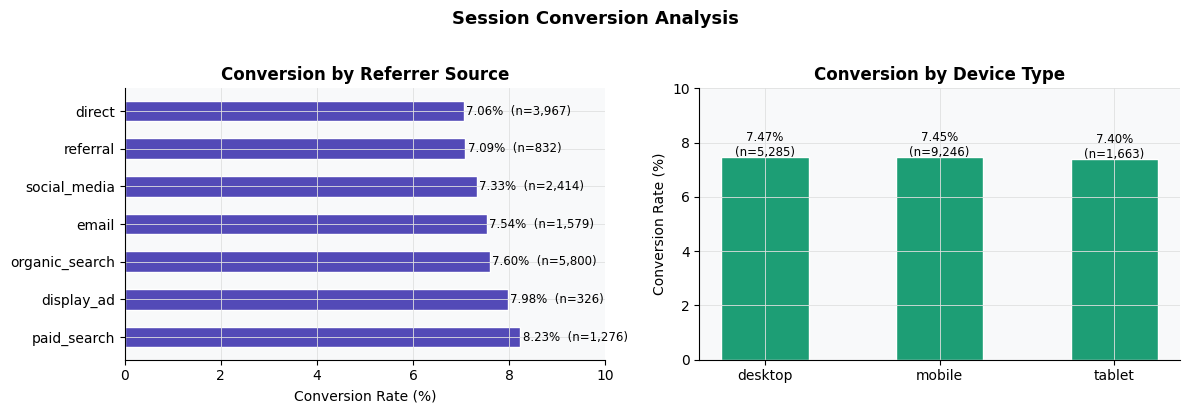

                 total converted conv_rate
referrer_source                           
paid_search       1276       105   8.22884
display_ad         326        26   7.97546
organic_search    5800       441  7.603448
email             1579       119  7.536415
social_media      2414       177  7.332229
referral           832        59  7.091346
direct            3967       280   7.05823


In [8]:
ref_conv = (sessions.groupby('referrer_source')
            .agg(total=('session_id','count'), converted=('is_converted','sum'))
            .assign(conv_rate=lambda x: x['converted']/x['total']*100)
            .sort_values('conv_rate', ascending=False))

dev_conv = (sessions.groupby('device_type')
            .agg(total=('session_id','count'), converted=('is_converted','sum'))
            .assign(conv_rate=lambda x: x['converted']/x['total']*100)
            .sort_values('conv_rate', ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Referrer
ax1.barh(ref_conv.index, ref_conv['conv_rate'], color=PALETTE[0], edgecolor='white', height=0.55)
for i, (idx, row) in enumerate(ref_conv.iterrows()):
    ax1.text(row['conv_rate'] + 0.05, i, f"{row['conv_rate']:.2f}%  (n={row['total']:,})",
             va='center', fontsize=8.5)
ax1.set_xlim(0, 10)
ax1.set_xlabel('Conversion Rate (%)')
ax1.set_title('Conversion by Referrer Source', fontweight='bold')

# Device
bars2 = ax2.bar(dev_conv.index, dev_conv['conv_rate'], color=PALETTE[1], edgecolor='white', width=0.5)
for bar, (_, row) in zip(bars2, dev_conv.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{row['conv_rate']:.2f}%\n(n={row['total']:,})", ha='center', fontsize=8.5)
ax2.set_ylim(0, 10)
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Conversion by Device Type', fontweight='bold')

plt.suptitle('Session Conversion Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('conversion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(ref_conv.to_string())


## 7. Revenue by Customer Loyalty Tier

LOYALTY TIER ANALYSIS
              customers  total_revenue  avg_spend  rev_per_customer
loyalty_tier                                                       
bronze              996       99547.19      73.79             99.95
silver              198       20048.89      75.09            101.26
gold                 70        7692.80      80.98            109.90
platinum             23        2221.97      85.46             96.61


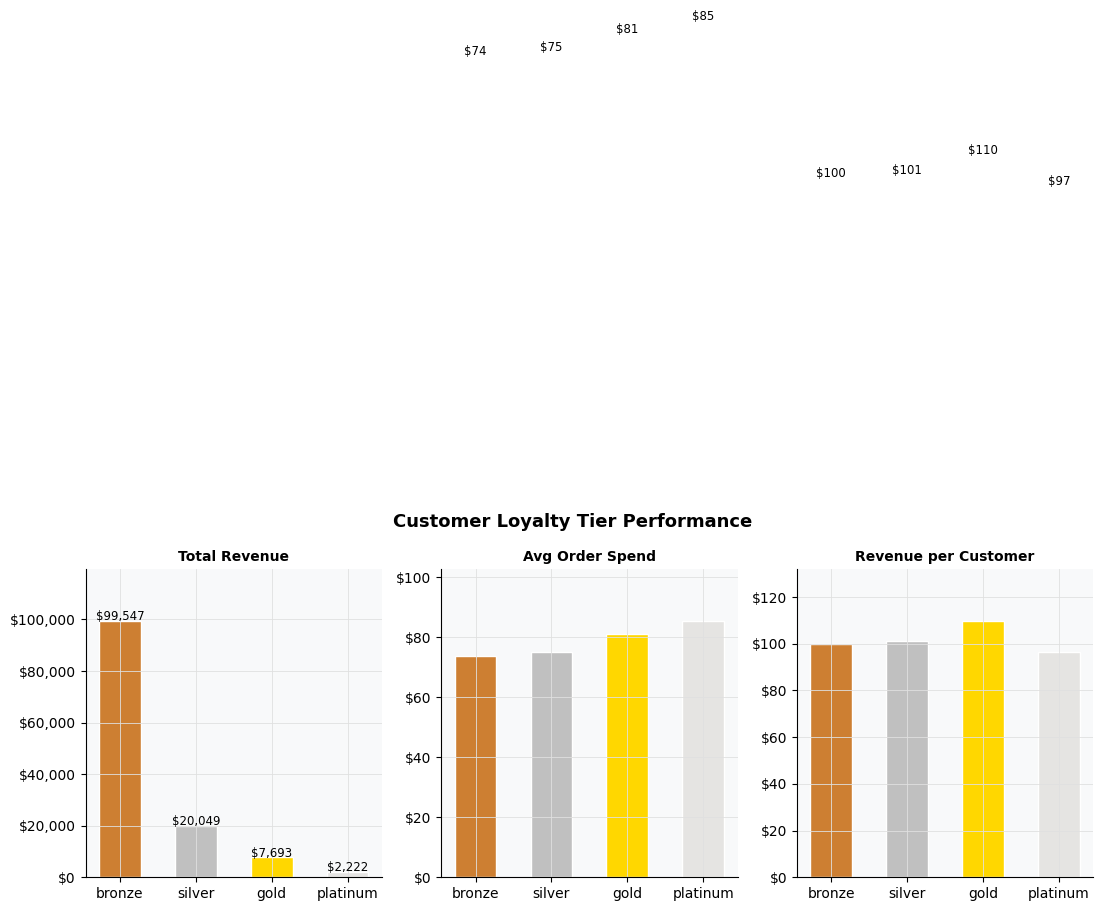

In [9]:
user_purch = purchases.merge(
    users[['user_id','loyalty_tier','income_level','age','gender']],
    on='user_id', how='left'
)
tier_order = ['bronze','silver','gold','platinum']
tier_stats = (user_purch.groupby('loyalty_tier')
              .agg(customers=('user_id','nunique'),
                   total_revenue=('total_amount','sum'),
                   avg_spend=('total_amount','mean'))
              .reindex(tier_order))

# Revenue per customer
tier_stats['rev_per_customer'] = tier_stats['total_revenue'] / tier_stats['customers']

print("LOYALTY TIER ANALYSIS")
print(tier_stats.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
tier_colors = ['#CD7F32','#C0C0C0','#FFD700','#E5E4E2']

for ax, col, title in zip(axes,
        ['total_revenue','avg_spend','rev_per_customer'],
        ['Total Revenue','Avg Order Spend','Revenue per Customer']):
    bars = ax.bar(tier_stats.index, tier_stats[col], color=tier_colors, edgecolor='white', width=0.55)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'${bar.get_height():,.0f}', ha='center', fontsize=8.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_ylim(0, tier_stats[col].max() * 1.2)

plt.suptitle('Customer Loyalty Tier Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loyalty_tiers.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Interaction Type Breakdown & Dwell Time

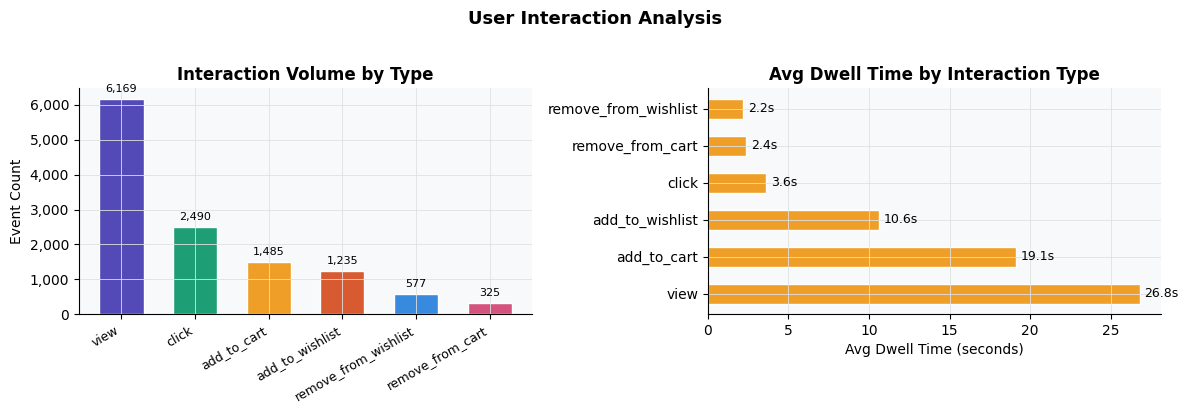

In [10]:
itype_counts = interactions['interaction_type'].value_counts()
dwell_by_type = (interactions.groupby('interaction_type')['dwell_time_ms'].mean() / 1000).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Volume
colors_i = PALETTE[:len(itype_counts)]
ax1.bar(itype_counts.index, itype_counts.values, color=colors_i, edgecolor='white', width=0.6)
ax1.set_xticklabels(itype_counts.index, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Event Count')
ax1.set_title('Interaction Volume by Type', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', fontsize=8)

# Dwell time
dwell_sorted = dwell_by_type.sort_values(ascending=False)
ax2.barh(dwell_sorted.index, dwell_sorted.values, color=PALETTE[2], edgecolor='white', height=0.55)
for i, (idx, val) in enumerate(dwell_sorted.items()):
    ax2.text(val + 0.3, i, f'{val}s', va='center', fontsize=9)
ax2.set_xlabel('Avg Dwell Time (seconds)')
ax2.set_title('Avg Dwell Time by Interaction Type', fontweight='bold')

plt.suptitle('User Interaction Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('interactions_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Top 10 Products by Revenue

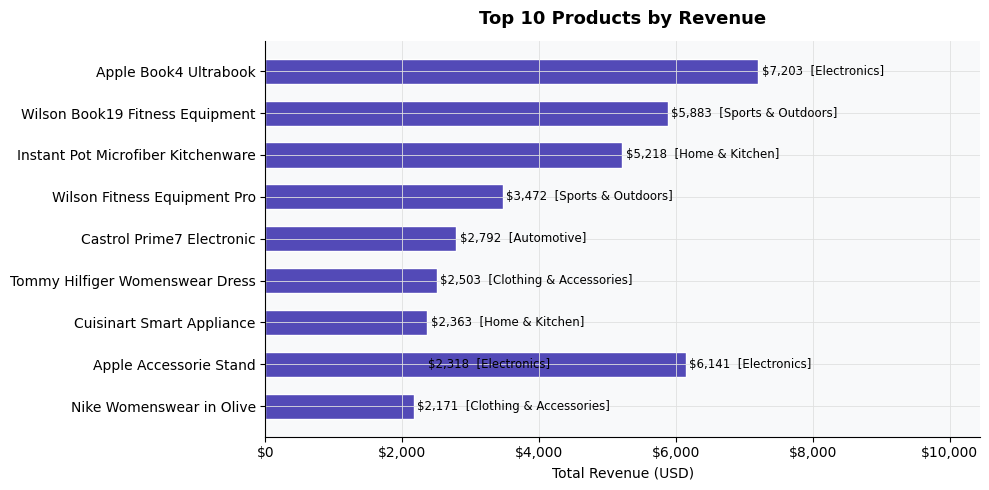

                      product_name               category  total_amount
             Apple Book4 Ultrabook            Electronics       7202.93
            Apple Accessorie Stand            Electronics       6140.92
   Wilson Book19 Fitness Equipment      Sports & Outdoors       5883.08
Instant Pot Microfiber Kitchenware         Home & Kitchen       5218.45
      Wilson Fitness Equipment Pro      Sports & Outdoors       3471.85
         Castrol Prime7 Electronic             Automotive       2791.99
   Tommy Hilfiger Womenswear Dress Clothing & Accessories       2503.33
         Cuisinart Smart Appliance         Home & Kitchen       2363.42
            Apple Accessorie Stand            Electronics       2318.48
          Nike Womenswear in Olive Clothing & Accessories       2170.90


In [11]:
top10 = (purch_prod.groupby(['product_id','product_name','category'])['total_amount']
         .sum().sort_values(ascending=False).head(10).reset_index())
top10['short_name'] = top10['product_name'].str[:35]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['short_name'][::-1], top10['total_amount'][::-1],
               color=PALETTE[0], edgecolor='white', height=0.6)
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"${bar.get_width():,.0f}  [{row['category']}]", va='center', fontsize=8.5)
ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, top10['total_amount'].max() * 1.45)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print(top10[['product_name','category','total_amount']].to_string(index=False))


## 10. Revenue by Income Level & Gender

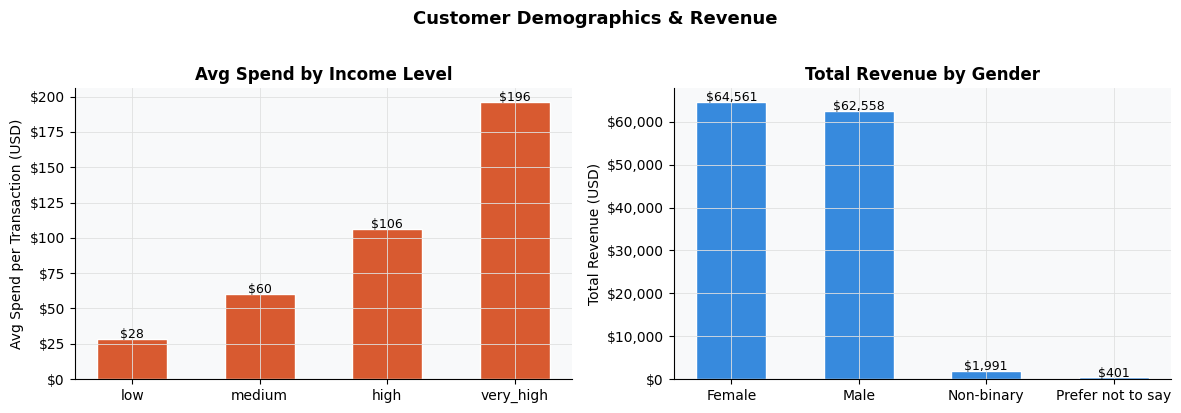


Income Level Detail:
              customers  total_revenue  avg_spend
income_level                                     
low                 338       12958.32      28.23
medium              513       41313.00      60.05
high                326       47604.40     106.02
very_high           110       27635.13     195.99


In [12]:
income_order = ['low','medium','high','very_high']
income_rev = (user_purch.groupby('income_level')
              .agg(customers=('user_id','nunique'),
                   total_revenue=('total_amount','sum'),
                   avg_spend=('total_amount','mean'))
              .reindex(income_order))

gender_rev = (user_purch.groupby('gender')
              .agg(customers=('user_id','nunique'),
                   total_revenue=('total_amount','sum'),
                   avg_spend=('total_amount','mean'))
              .sort_values('total_revenue', ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Income
ax1.bar(income_rev.index, income_rev['avg_spend'], color=PALETTE[3], edgecolor='white', width=0.55)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'${bar.get_height():,.0f}', ha='center', fontsize=9)
ax1.set_ylabel('Avg Spend per Transaction (USD)')
ax1.set_title('Avg Spend by Income Level', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Gender
ax2.bar(gender_rev.index, gender_rev['total_revenue'], color=PALETTE[4], edgecolor='white', width=0.55)
for bar in ax2.patches:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${bar.get_height():,.0f}', ha='center', fontsize=9)
ax2.set_ylabel('Total Revenue (USD)')
ax2.set_title('Total Revenue by Gender', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Customer Demographics & Revenue', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('demographics_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nIncome Level Detail:")
print(income_rev.round(2).to_string())


## 11. Review Rating Distribution

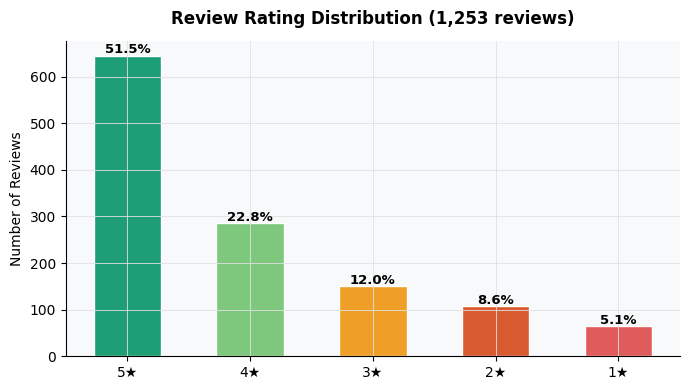

Average Rating: 4.07 / 5.00
Review coverage: 452 products have reviews (45.2% of catalog)


In [13]:
rat_dist = reviews['rating'].value_counts().sort_index(ascending=False)
rat_pct  = (rat_dist / rat_dist.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
star_colors = [PALETTE[1], '#7dc87d', PALETTE[2], PALETTE[3], '#e05c5c']
bars = ax.bar([f'{r}★' for r in rat_dist.index], rat_dist.values,
              color=star_colors, edgecolor='white', width=0.55)
for bar, pct in zip(bars, rat_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{pct}%', ha='center', fontsize=9.5, fontweight='bold')
ax.set_ylabel('Number of Reviews')
ax.set_title('Review Rating Distribution (1,253 reviews)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

avg_rating = (reviews['rating'] * 1).mean()
print(f"Average Rating: {avg_rating:.2f} / 5.00")
print(f"Review coverage: {reviews['product_id'].nunique()} products have reviews ({reviews['product_id'].nunique()/1000*100:.1f}% of catalog)")


## 12. Key Business Insights

| # | Insight | Value |
|---|---------|-------|
| 1 | **Funnel drop-off** | Only 13% of users who had a session made a purchase |
| 2 | **Electronics dominance** | 31% of all revenue from Electronics category alone |
| 3 | **Display Ads convert best** | 8.05% conversion rate vs 7.24% for social media |
| 4 | **Mobile is dominant** | 57% of sessions come from mobile (but slight edge over desktop in conversion) |
| 5 | **Loyalty paradox** | Bronze tier (79% of customers) drives 77% of revenue — platinum spends most per transaction ($85 avg) |
| 6 | **Very high income = highest spend** | very_high income users average $196/transaction vs $28 for low income |
| 7 | **Cold-start challenge** | 30.6% of users have no interactions — key challenge for recommendation engine |
| 8 | **Reviews skew positive** | 74.3% of reviews are 4★ or 5★ |
| 9 | **Revenue growing** | Monthly revenue ~26x higher in May 2026 ($5,054) vs Jan 2023 ($197) |
| 10 | **Cart-to-purchase rate** | ~26.7% of users who added to cart actually purchased |

---
*Analysis by Holarbrain · github.com/holarbrain*
